<a href="https://colab.research.google.com/github/sergo8online/CIFAR-10-with-MLP/blob/main/Problem_CIFAR10_With_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torchmetrics
import torch
from torch import nn
import matplotlib.pyplot as plt
import torchvision
from torchvision import transforms
from torchvision.transforms import ToTensor, Normalize, RandomHorizontalFlip, Resize
from torchvision import datasets
from torchmetrics import Accuracy

print(torch.__version__)
print(torchvision.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 23.2 MB/s eta 0:00:00
2.10.0+cu128
0.25.0+cu128


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
torch.manual_seed(42)
train_transform = transforms.Compose([Resize((64, 64)),
                                RandomHorizontalFlip(),
                                ToTensor(),
                                Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
test_transform = transforms.Compose([Resize((64, 64)),
                                    ToTensor(),
                                    Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

In [ ]:
torch.manual_seed(42)
train_data = datasets.CIFAR10(root="data",
                              train=True,
                              transform=train_transform,
                              target_transform=None,
                              download=True)
test_data = datasets.CIFAR10(root='data',
                             train=False,
                             transform=test_transform,
                             target_transform=None,
                             download=True)

100%|██████████| 170M/170M [00:08<00:00, 20.6MB/s]


In [ ]:
len(train_data), len(test_data)

(50000, 10000)

In [ ]:
classes = train_data.classes
classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [ ]:
train_data.class_to_idx

{'airplane': 0,
 'automobile': 1,
 'bird': 2,
 'cat': 3,
 'deer': 4,
 'dog': 5,
 'frog': 6,
 'horse': 7,
 'ship': 8,
 'truck': 9}

In [ ]:
image, label = train_data[0]
image.size()                         #so it is channel first, ok, and also 32*32

torch.Size([3, 64, 64])

In [ ]:
import random

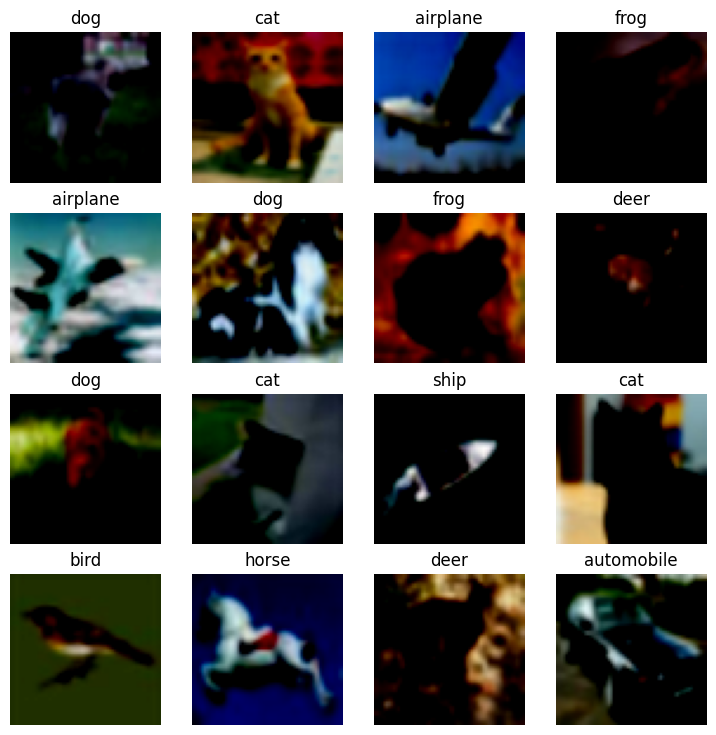

In [ ]:
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows*cols+1):
  idx = random.randint(0, len(train_data))
  image, label = train_data[idx]
  image = torch.permute(image, (1, 2, 0))
  fig.add_subplot(rows, cols, i)
  plt.title(classes[label])
  plt.imshow(image)
  plt.axis(False)

In [ ]:
idx = random.randint(0, len(train_data))
image, label = train_data[idx]
flatten = nn.Flatten()
linear = nn.Linear(in_features = 4096,
                   out_features = len(classes))
flatten(image).shape
A = linear(flatten(image))
print(A)
print()
y_logit = torch.softmax(A, dim=1).argmax(dim=1)
y_logit

tensor([[-0.0960,  0.2131, -0.0530,  0.1387,  0.0594,  0.1784,  0.0188,  0.0360,
          0.1700, -0.0032],
        [-0.1003,  0.2002,  0.0276,  0.0922,  0.0969,  0.2058,  0.0543,  0.0377,
          0.1076,  0.0129],
        [-0.0975,  0.1538,  0.0845,  0.0738,  0.1478,  0.1230,  0.1131,  0.0120,
         -0.0083,  0.0054]], grad_fn=<AddmmBackward0>)



tensor([1, 5, 1])

In [ ]:
from torch.utils.data import DataLoader
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=32,
                              shuffle=True)
test_dataloader = DataLoader(dataset = test_data,
                             batch_size=32,
                             shuffle=False)

In [ ]:
class MLP(nn.Module):
  def __init__(self, input_shape, output_shape):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,
                  out_features = 2048),
        nn.BatchNorm1d(2048),
        nn.LeakyReLU(),
        nn.Dropout(0.3),
        nn.Linear(in_features=2048,
                  out_features = 512),
        nn.BatchNorm1d(512),
        nn.LeakyReLU(),
        nn.Dropout(0.3),
        nn.Linear(in_features = 512,
                  out_features=128),
        nn.BatchNorm1d(128),
        nn.LeakyReLU(),
        nn.Dropout(0.3),
        nn.Linear(in_features=128,
                  out_features = 32),
        nn.BatchNorm1d(32),
        nn.LeakyReLU(),
        nn.Dropout(0.3),
        nn.Linear(in_features = 32,
                  out_features = output_shape)
    )
  def forward(self, x):
    return self.layer_stack(x)

In [ ]:
torch.manual_seed(42)
model_mlp = MLP(input_shape = 3*64*64,
                output_shape = len(classes)).to(device)
model_mlp

MLP(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=12288, out_features=2048, bias=True)
    (2): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=2048, out_features=512, bias=True)
    (6): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.01)
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=512, out_features=128, bias=True)
    (10): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): LeakyReLU(negative_slope=0.01)
    (12): Dropout(p=0.3, inplace=False)
    (13): Linear(in_features=128, out_features=32, bias=True)
    (14): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (15): LeakyReLU(negative_slope=0.01)
    (16): Dropout(p=0.3, inpla

In [ ]:
loss_fn = nn.CrossEntropyLoss()
acc_fn = Accuracy(task='multiclass', num_classes = len(classes))
optimizer = torch.optim.Adam(params = model_mlp.parameters())

In [ ]:
X_dummy = torch.rand(32, 3, 64, 64).to(device)
y_logits = model_mlp(X_dummy)
y_proba = torch.softmax(y_logits, dim=1)
y_preds = y_proba.argmax(dim=1)
print(y_logits[:1, :])
print(y_proba[:1, :])
print(y_preds[0])

tensor([[ 0.2838, -1.3786,  0.9216, -0.9055, -0.4066, -0.3873, -1.2067,  0.3853,
          0.1694,  0.7890]], device='cuda:0', grad_fn=<SliceBackward0>)
tensor([[0.1208, 0.0229, 0.2285, 0.0368, 0.0606, 0.0617, 0.0272, 0.1337, 0.1077,
         0.2001]], device='cuda:0', grad_fn=<SliceBackward0>)
tensor(2, device='cuda:0')


In [ ]:
lambda_reg = 0.0001
def train_step(model: nn.Module,
               data_loader: DataLoader,
               loss_fn: nn.Module,
               acc_fn,
               optimizer: torch.optim,
               device: torch.device):
  model = model.to(device)
  model.train()
  acc_fn = acc_fn.to(device)

  train_loss, train_acc = 0, 0

  for X, y in data_loader:
    X, y = X.to(device), y.to(device)

    y_logits = model(X)
    y_preds = torch.softmax(y_logits, dim=1).argmax(dim=1)

    loss = loss_fn(y_logits, y)
    acc = acc_fn(y_preds, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_loss += loss
    train_acc += acc

  train_loss /= len(data_loader)
  train_acc /= len(data_loader)

  print(f"Train Loss: {train_loss} | Train Acc: {train_acc}")

In [ ]:
def test_step(model: nn.Module,
              data_loader: DataLoader,
              loss_fn: nn.Module,
              acc_fn,
              device: torch.device):
  model = model.to(device)
  model.eval()
  acc_fn = acc_fn.to(device)
  test_loss, test_acc = 0, 0

  with torch.inference_mode():
    for X, y in data_loader:
      X, y = X.to(device), y.to(device)

      y_logits = model(X)
      y_preds = torch.softmax(y_logits, dim=1).argmax(dim=1)

      test_loss += loss_fn(y_logits, y)
      test_acc += acc_fn(y_preds, y)

    test_loss /= len(data_loader)
    test_acc /= len(data_loader)

  print(f"Test Loss: {test_loss} | Test Acc: {test_acc}")

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
from tqdm.auto import tqdm
epochs = 100
for epoch in tqdm(range(epochs)):
  print(f"Epoch ========> {epoch}")
  train_step(model = model_mlp,
             data_loader=train_dataloader,
             loss_fn = loss_fn,
             acc_fn = acc_fn,
             optimizer = optimizer,
             device = device)
  test_step(model = model_mlp,
            data_loader = test_dataloader,
            loss_fn = loss_fn,
            acc_fn = acc_fn,
            device = device)

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch ========> 0
Train Loss: 1.8616770505905151 | Train Acc: 0.3315539062023163
Test Loss: 1.6086593866348267 | Test Acc: 0.4315095841884613
Epoch ========> 1
Train Loss: 1.6919680833816528 | Train Acc: 0.40427064895629883
Test Loss: 1.5359233617782593 | Test Acc: 0.45527157187461853
Epoch ========> 2
Train Loss: 1.621533751487732 | Train Acc: 0.43202176690101624
Test Loss: 1.448508381843567 | Test Acc: 0.49061501026153564
Epoch ========> 3
Train Loss: 1.5705546140670776 | Train Acc: 0.4481365978717804
Test Loss: 1.3944542407989502 | Test Acc: 0.5010982155799866
Epoch ========> 4
Train Loss: 1.5373691320419312 | Train Acc: 0.4616522789001465
Test Loss: 1.36808443069458 | Test Acc: 0.5189696550369263
Epoch ========> 5
Train Loss: 1.5016933679580688 | Train Acc: 0.47542786598205566
Test Loss: 1.342973232269287 | Test Acc: 0.5235623121261597
Epoch ========> 6
Train Loss: 1.4782146215438843 | Train Acc: 0.4877239167690277
Test Loss: 1.3250501155853271 | Test Acc: 0.533845841884613
Epoch =

# Մեկնաբանություններ

այստեղ ես կնկարագրեմ թե ինչեր եմ արել ու որը ինչ արդյունք է տվել։
քայլերը դասավորված են ժամանակագրական հաջորդականությամբ։
Սկզբնական պահին

--->
*   model = {Flatten,
            Linear(3072, 512),
            Linear(512, 128),
            Linear(128, 32),
            Linear(32, 10)}
*   optimizer = SGD(lr=0.1)
*   epochs = 10

**Արդյունքներ**


*   test accuracy = 0.33

**Խնդիրներ**


*   Թռչկոտող գրադիենտներ, որի հետևանքով թեստի accuracy-ն չի աճում։

**Լուծում**


*   lr = 0.01
*   momentum = 0.2

**Հետևանք**


*   train accuracy = 0.4
*   test accuracy = 0.39

**Խնդիր**

*   մոդելում չկա ոչ գծայնություն

**Լուծում**

*   Փորձ ենք որպես ակտիվացման ֆունկցիյա ավելացնել Relu, leakyRelu կամ Tanh

**Հետևանք**

*   Relu -------> train = 0.5, test = 0.48
*   leakyRelu --> train = 0.51 test = 0.48
*   Tanh--------> train = 0.21 test = 0.22

Հետևաբար ընտրեցինք LeakyRelu-ն

**Խնդիր**


*   չկա նորմալիզացիյա


**Լուծում**


*   Օգտագործ ենք torchvision.transforms.Normalize
*   Օգտագործ ենք նաև nn.BatchNorm1d


**Արդյունք**


*   Միայն տվյալների նորմալիզացիաով --> train = 0.68, test = 0.53
*   Երկուսը իրար հետ ----------------> train = 0.64, test = 0.55


**Խնդիր**


*   Քանի որ train և test accuracy ները ահագին տարբերվում են կա մեծ ռիսկ overfit-ի

**Լուծում**


*   ավելացնենք Dropout 0.3-ով կամ 0.1-ով
*   անել աուգմենտացիա Resize((64, 64)) և RandomHorizontalFlip()

**Արդյունքներ**

*   Dropout(0.1)-ը 10 epoch-ի վրա տալիս է train = 0.58, test = 0.56, բայց լավ չի ցույց տալիս իրան 100 epoch-ի դեպքում -> train = 0.66, test = 0.56։ Իսկ Dropout(0.3)-ը հակառակը, դրա համար ես ընտրել եմ 0․3-ը։  
*   սրան ավելացրած աուգմենտացիան ստացվում է հետևյալը։
10 epoch ---> train = 0.54, test = 0.56
20 epoch ---> train = 0.59, test = 0.59
100 epoch --> train = 0.71, test = 0.63